# 1. Análisis exploratorio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Carga de datos y exploración inicial

## Diccionario de variables

### Fichero de movimiento (`wsdr.csv`) — ventas semanales por tienda y producto

| Variable    | Descripción |
|-------------|-------------|
| `STORE`     | Número de tienda de Dominick's. |
| `UPC`       | Código de producto (Universal Product Code). Clave para unir con el catálogo. |
| `WEEK`      | Índice de semana interno de Dominick's (no es una fecha; se mapea con la tabla de semanas). |
| `MOVE`      | Unidades vendidas en esa tienda y semana. Es la demanda. |
| `QTY`       | Nº de unidades que forman el paquete de venta (p. ej. 3 en "3 por 2$"). |
| `PRICE`     | Precio de venta del paquete. El precio unitario es `PRICE / QTY`. |
| `SALE` | Código de promoción de la semana: `B` = bonus buy, `C` = cupón, `S` = rebaja simple; en blanco = precio regular. (`G` aparece en los datos pero no está en el codebook oficial → se trata como promoción no documentada. Aviso: la variable no se rellena de forma consistente, un blanco no garantiza ausencia de promoción.) |
| `PROFIT`    | Margen bruto del minorista, en %. Permite optimizar margen, no solo ingreso. |
| `OK`        | Flag de calidad del dato: 1 = fiable, 0 = posible problema. |
| `PRICE_HEX` | Precio en hexadecimal a precisión completa. Se ignora (usamos `PRICE`). |
| `PROFIT_HEX`| Margen en hexadecimal a precisión completa. Se ignora (usamos `PROFIT`). |

### Catálogo de productos (`upcsdr.csv`) — un registro por UPC

| Variable    | Descripción |
|-------------|-------------|
| `com_code`  | Código de *commodity*: clasificación interna de Dominick's que agrupa productos afines. |
| `upc`       | Código de producto. Clave para unir con el fichero de movimiento. |
| `descrip`   | Descripción del producto (marca y tipo). |
| `size`      | Tamaño o formato del envase (p. ej. "2 LTR", "12 PK"). |
| `case`      | Unidades por caja (formato de compra al por mayor). |
| `nitem`     | Número de ítems / identificador interno del producto. |

### Calendario (`weeks.csv`)
| Variable    | Descripción |
|-------------|-------------|
| `special` | Festividad de la semana (Navidad, Acción de Gracias, etc.); vacío = semana sin festividad señalada. Control necesario para no confundir el efecto del precio con el de la fecha. |

In [2]:
RAW = '../data/raw' # Ruta a los datos
mov = pd.read_csv(f'{RAW}/wsdr.csv')
upc = pd.read_csv(f'{RAW}/upcsdr.csv', encoding='latin-1')

In [3]:
print(mov.shape) # Forma de mov
mov.head()

(17730501, 11)


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,PRICE_HEX,PROFIT_HEX
0,2,179,1,1,1,10.0,NaN,99.9,1,4024000000000000,4058F9999999999A
1,2,179,2,0,1,0.0,NaN,0.0,1,0000000000000000,0000000000000000
2,2,179,3,0,1,0.0,NaN,0.0,1,0000000000000000,0000000000000000
3,2,179,4,2,1,10.0,NaN,99.9,1,4024000000000000,4058F9999999999A
4,2,179,5,0,1,0.0,NaN,0.0,1,0000000000000000,0000000000000000


In [4]:
mov.info()
mov.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17730501 entries, 0 to 17730500
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   STORE       int64  
 1   UPC         int64  
 2   WEEK        int64  
 3   MOVE        int64  
 4   QTY         int64  
 5   PRICE       float64
 6   SALE        object 
 7   PROFIT      float64
 8   OK          int64  
 9   PRICE_HEX   object 
 10  PROFIT_HEX  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.5+ GB


,STORE,UPC,WEEK,MOVE,QTY,PRICE,PROFIT,OK
count,1.773050e+07,1.773050e+07,1.773050e+07,1.773050e+07,1.773050e+07,1.773050e+07,1.773050e+07,1.773050e+07
mean,8.393260e+01,4.617154e+09,2.343443e+02,1.706751e+01,1.056829e+00,1.428817e+00,1.180705e+01,9.856988e-01
std,3.676353e+01,5.256305e+09,1.116569e+02,8.765091e+01,5.609347e-01,1.865940e+00,1.965496e+01,1.187296e-01
min,2.000000e+00,1.790000e+02,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-9.999000e+01,0.000000e+00
25%,5.600000e+01,1.690002e+09,1.510000e+02,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,9.000000e+01,4.300095e+09,2.470000e+02,2.000000e+00,1.000000e+00,8.900000e-01,4.030000e+00,1.000000e+00
75%,1.140000e+02,7.020270e+09,3.310000e+02,1.000000e+01,1.000000e+00,2.000000e+00,2.465000e+01,1.000000e+00
max,1.460000e+02,7.714348e+10,3.990000e+02,9.999900e+04,2.400000e+01,1.188800e+02,9.999000e+01,1.000000e+00


In [5]:
mov.columns.tolist()
print(f'Nº tiendas únicas: {mov["STORE"].nunique()}'), print(f'Nº productos únicos: {mov["UPC"].nunique()}') # número de tiendas y productos únicos
print('-'*15)
print(f'Fecha semana mínima: {mov["WEEK"].min()}'), print(f'Fecha semana máxima: {mov["WEEK"].max()}') # valor mínimo y máximo de semanas
print('-'*15)
print(f'Calidad del dato: {mov["OK"].value_counts(dropna=False)}')
print('-'*15)
print(f'Información sobre promociones: {mov["SALE"].value_counts(dropna=False)}')
print('-'*15)
print('Valores ausentes')
mov.isna().sum()

Nº tiendas únicas: 93
Nº productos únicos: 1720
---------------
Fecha semana mínima: 1
Fecha semana máxima: 399
---------------
Calidad del dato: OK
1    17476933
0      253568
Name: count, dtype: int64
---------------
Información sobre promociones: SALE
NaN    14287219
B       1666010
S       1664212
G         73034
C         40026
Name: count, dtype: int64
---------------
Valores ausentes


STORE                0
UPC                  0
WEEK                 0
MOVE                 0
QTY                  0
PRICE                0
SALE          14287219
PROFIT               0
OK                   0
PRICE_HEX            0
PROFIT_HEX           0
dtype: int64

In [6]:
print(upc.shape)
upc.head()

(1746, 6)


,COM_CODE,UPC,DESCRIP,SIZE,CASE,NITEM
0,225,179,BLOOD GLUCOSE SCREEN,EACH,1,9990290
1,235,418,~DIET CRYSTAL PEPSI,24/12O,1,54950
2,235,419,~CRYSTAL PEPSI 24 PA,24/12O,1,54940
3,235,420,PEPSI COLA CANS,24/12O,1,54880
4,235,421,PEPSI DIET CANS,24/12O,1,54890


Tras un pequeño vistazo inicial, para la tabla `mov` vamos a eliminar las columnas con el `PRICE_HEX` y `PROFIT_HEX` para liberar espacio, ya que son columnas que no van a ser utilizadas. Por otro lado, la ausencia de valores en `SALE` se debe a que esta variable registra las fechas festivas.

In [7]:
mov = mov.drop(columns=['PRICE_HEX', 'PROFIT_HEX'])

La variable `OK` de la tabla `mov` proporciona información sobre la calidad del dato, lo que nos puede llevar a plantear la eliminación de los registros que no cumplen con la calidad del dato. Antes de eliminar, se realiza un análisis rápido de esta variable para determinar la acción a realizar.

In [8]:
flagged = mov[mov['OK'] == 0] # Seleccionamos registros que no cumplen calidad
print(flagged[['PRICE','MOVE','PROFIT']].describe())

               PRICE           MOVE         PROFIT
count  253568.000000  253568.000000  253568.000000
mean        0.611474      19.572604       6.409334
std         1.334854     412.815302      13.328842
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         0.000000       0.000000       0.000000
75%         0.690000       1.000000       2.630000
max        10.000000   99999.000000      99.990000


Se puede ver como en la columnas seleccionadas el valor es principalmente 0. Esto nos lleva a eliminar estos registros para evitar futuros problemas.

In [9]:
mov = mov[mov['OK'] == 1].copy() # Filtramos tabla mov para quedar con registros que cumplen calidad de dato.
mov.shape

(17476933, 9)

In [10]:
print((mov["PRICE"] == 0).sum()) # Comprobamos precios
print('-'*15)
mov[(mov["PRICE"] == 0)].head()

6735190
---------------


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK
1,2,179,2,0,1,0.0,NaN,0.0,1
2,2,179,3,0,1,0.0,NaN,0.0,1
4,2,179,5,0,1,0.0,NaN,0.0,1
6,2,179,7,0,1,0.0,NaN,0.0,1
8,2,179,9,0,1,0.0,NaN,0.0,1


Con los datos filtrados donde cumplen la calidad del dato, seguimos teniendo precios con valor 0. Seguimos profundizando en el análisis para comprender mejor este fenómeno

In [11]:
# Miramos si hay ventas con precio 0
print(((mov["PRICE"] == 0) & (mov["MOVE"] > 0)).sum())

0


La conclusión alcanzada es que se trata de semanas en donde el producto no se ha vendido. Para evitar problemas futuros, volvemos a filtrar la tabla para quedarnos solo con registros en donde hay movimiento, es decir, en donde el producto se ha vendido.

In [12]:
mov = mov[mov['PRICE'] > 0].copy()
mov.shape

(10741743, 9)

Antes de unir las dos tablas y transformar la columna `WEEK` para crear un índice de fechas, vamos a comprobar que las tablas coinciden y no hay duplicados.

In [13]:
# Comprobamos si hay duplicados
print(f"Valores duplicados: {mov.duplicated(subset=['STORE', 'UPC', 'WEEK']).sum()}")
print('-'*15)
# Compatibilidad de clave entre tablas
print(mov['UPC'].dtype), print(upc['UPC'].dtype) # Deben coincidir ambos tipos
print('-'*15)
print(f"Fracción de filas compatible: {mov['UPC'].isin(upc['UPC']).mean()}")
print('-'*15)
upc['UPC'].duplicated().sum() # Comprobamos presencia de valores duplicados en catálogo.

Valores duplicados: 0
---------------
int64
int64
---------------
Fracción de filas compatible: 1.0
---------------


np.int64(0)

Cargamos datos los datos de calendario para poder incluir fechas a la tabla. Las fechas están en formato americano (`MM-DD-YYYY`) por lo que hay que tener cuidado a la hora de leerlas. De forma interna, pandas no va a tener problema, es más una cuestión de usuario. Al emplear el método `to_datetime` el formato que devuelve pandas es `YYYY-MM-DD`.

In [14]:
weeks = pd.read_csv(
    f'{RAW}/weeks.csv',
    header= None,
    names= ['WEEK', 'start', 'end', 'special']
)

weeks['start'] = pd.to_datetime(weeks['start'], format='%m/%d/%y')
weeks['end'] = pd.to_datetime(weeks['end'], format='%m/%d/%y')

weeks.head()

,WEEK,start,end,special
0,1,1989-09-14,1989-09-20,NaN
1,2,1989-09-21,1989-09-27,NaN
2,3,1989-09-28,1989-10-04,NaN
3,4,1989-10-05,1989-10-11,NaN
4,5,1989-10-12,1989-10-18,NaN


In [15]:
# Unimos mov y upc
mov = mov.merge(
    upc[['UPC','DESCRIP','SIZE','COM_CODE']],
    left_on='UPC', right_on='UPC', how='left'
)

mov['DESCRIP'].isna().mean() # cobertura

np.float64(0.0)

In [16]:
# Unimos al calendario
mov = mov.merge(
    weeks[['WEEK','start', 'end', 'special']],
    on='WEEK', how='left'
)

mov['start'].isna().sum() # comprobación de que no hay nulos.

np.int64(0)

In [17]:
mov.shape
mov

,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,DESCRIP,SIZE,COM_CODE,start,end,special
0,2,179,1,1,1,10.00,NaN,99.90,1,BLOOD GLUCOSE SCREEN,EACH,225,1989-09-14,1989-09-20,NaN
1,2,179,4,2,1,10.00,NaN,99.90,1,BLOOD GLUCOSE SCREEN,EACH,225,1989-10-05,1989-10-11,NaN
2,2,179,6,1,1,10.00,NaN,99.90,1,BLOOD GLUCOSE SCREEN,EACH,225,1989-10-19,1989-10-25,NaN
3,2,179,8,1,1,10.00,NaN,99.90,1,BLOOD GLUCOSE SCREEN,EACH,225,1989-11-02,1989-11-08,NaN
4,2,179,10,2,1,10.00,NaN,99.90,1,BLOOD GLUCOSE SCREEN,EACH,225,1989-11-16,1989-11-22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10741738,136,75220812054,361,5,1,0.99,NaN,25.95,1,WEST END NON-CARB TR,20 OZ,234,1996-08-08,1996-08-14,NaN
10741739,137,75220812054,358,7,1,0.99,NaN,25.95,1,WEST END NON-CARB TR,20 OZ,234,1996-07-18,1996-07-24,NaN
10741740,137,75220812054,359,5,1,0.99,NaN,25.95,1,WEST END NON-CARB TR,20 OZ,234,1996-07-25,1996-07-31,NaN
10741741,137,75220812054,360,6,1,0.99,NaN,25.95,1,WEST END NON-CARB TR,20 OZ,234,1996-08-01,1996-08-07,NaN


Observando los datos podemos ver como hay un salto entre fechas. No se trata de un error, sinó de como están ordenados los datos. Antes de nada vamos a eliminar la columna `OK` ya que no aporta valor y luego pasar el dataset a formato parquet. El archivo no va a recibir más transformaciones por lo que se pueden guardar los datos finales para las siguientes fases.

In [18]:
mov = mov.drop(columns=['OK'])
mov.to_parquet("../data/interim/soft_drinks_enriched.parquet")

In [19]:
# Semanas presentes en la categoría (de 400)
print(f'Semanas presentes en categoría: {mov["WEEK"].nunique()}')
print('-'*15)
# Cobertura por serie: en cuántas semanas hay dato en cada (tienda, producto)
cobertura = mov.groupby(["STORE", "UPC"])["WEEK"].nunique()
display(cobertura.describe())
print((cobertura >= 380).sum())          # nº de series casi completas (≥95% de las semanas)
print('-'*15)
# Confirmar el mecanismo: ¿quedan semanas con venta 0 y precio > 0?
(mov["MOVE"] == 0).sum()          # si es ~0, "precio>0" equivale a "hubo venta"

Semanas presentes en categoría: 390
---------------


count    104574.000000
mean        102.719060
std         110.519987
min           1.000000
25%          19.000000
50%          52.000000
75%         158.000000
max         389.000000
Name: WEEK, dtype: float64

3118
---------------


np.int64(0)

Una vez analizada la cobertura de fechas tenemos varias conclusiones:
- Tenemos una mediana de ventas por semana de 52 de 400 semanas que tiene el dataset. La gran parte de series no nos sirve porque estará principalmente vacía.
- Por otro lado, contamos con una cola densa de 3.118 series casi completas. Es aquí donde nos vamos a enfocar. Estos productos se venden casi todas las semanas.

Para modelos de ML que emplearemos más adelante, la ausencia de algunas fechas no es un problema, ya que el algoritmo puede trabajar con esa situación sin problema. El problema lo tendremos cuando apliquemos STL/ETS/ARIMA, en donde necesitamos indices de fechas completos.

A continuación vamos examinar que productos tienen esa alta densidad de fechas que buscamos para seleccionarlos.

In [20]:
# Composición de densidad por tienda y producto diferente
densas = cobertura[cobertura >= 380].reset_index() # 380 semanas.
print(f"Productos: {densas['UPC'].nunique()}"), print(f"Tiendas: {densas['STORE'].nunique()}")
print('-'*15)
densas['UPC'].value_counts().head(15)

Productos: 102
Tiendas: 62
---------------


UPC
1200000231    62
1200000230    62
3828100265    62
3828100253    62
3828100261    62
1690001601    61
1200000496    60
3828100321    60
1200000492    60
4900000639    59
3828100257    59
3828100277    57
1200000050    57
4900000663    57
3828100249    57
Name: count, dtype: int64

In [21]:
# Productos y volumen total
top_prod = (mov.groupby(['UPC', 'DESCRIP', 'SIZE'])['MOVE']
            .sum().sort_values(ascending=False).head(20))

display(top_prod)

# Tiendas más completas
densas['STORE'].value_counts().head(10)

UPC         DESCRIP               SIZE  
1200000230  PEPSI COLA N/R        2 LT      10042521
4900000639  COCA-COLA CLASSIC     2 LT       8327729
4900000663  DIET COKE             2 LT       5996860
7800000034  SEVEN-UP N/R          2 LT       5878735
3828100253  DOM COLA              12 OZ      5178055
1200000231  PEPSI DIET N/R        2 LT       5024990
3828100257  DOM CREME SODA        12 OZ      4956452
1200000013  PEPSI-COLA CANS       6/12OZ     4672830
3828100265  DOM ROOT BEER SODA    12 OZ      4376659
3828100249  DOM GINGER ALE        12 OZ      4203502
3828100261  DOM ORANGE SODA       12 OZ      4145547
420         PEPSI COLA CANS       24/12O     4009463
3828100317  DOM BLACK CHERRY SOD  12 OZ      3895257
3828100301  DOM LEMON LIME SODA   12 OZ      3768757
4900000634  COCA-COLA CLASSIC CA  6/12OZ     3721973
3828100305  DOM GRAPE SODA        12 OZ      3712338
3828100321  DOM FRUIT PUNCH       12 OZ      3269362
2950001933  RC COLA PPD $.99      2 LT       3238446
78000

STORE
101    80
121    78
122    77
112    77
80     75
132    75
83     67
78     67
109    67
115    63
Name: count, dtype: int64

Obtenemos una serie de productos top en ventas que también se encuentran al mismo tiempo en todas las tiendas, lo que es un buen inicio de cara al análisis temporal, en donde seleccionamos productos con una gran densidad. Antes de seleccionar un producto, vamos a ver como es la variación de precio en los top 5 productos más vendidos. Si el precio apenas varía, el análisis de elasticidad sobre ese producto tendría poco sentido.

In [22]:
mov['UNIT_PRICE'] = mov['PRICE'] / mov['QTY']

cand = [1200000230, 4900000639, 3828100253, 1200000231, 4900000663]

resumen = (
    mov[mov['UPC'].isin(cand)]
    .groupby(['UPC','DESCRIP','SIZE'])
    .agg(ventas_tot=('MOVE', 'sum'),
         precio_medio=('UNIT_PRICE', 'mean'),
         cv_precio=('UNIT_PRICE', lambda s: s.std() / s.mean()),
         n_tiendas=('STORE', 'nunique'))
    .sort_values('ventas_tot', ascending=False)
)

resumen

,,,ventas_tot,precio_medio,cv_precio,n_tiendas
UPC,DESCRIP,SIZE,,,,
1200000230,PEPSI COLA N/R,2 LT,10042521,1.368668,0.186834,93
4900000639,COCA-COLA CLASSIC,2 LT,8327729,1.359705,0.191371,93
4900000663,DIET COKE,2 LT,5996860,1.362920,0.191613,93
3828100253,DOM COLA,12 OZ,5178055,0.213508,0.144115,93
1200000231,PEPSI DIET N/R,2 LT,5024990,1.370591,0.186876,93


Observando los datos, para poder comparar más adelante diferentes productos, vamos a necesitar que todos se encuentran en la misma medida, por tanto de los 5 presentes, `DOM COLA` queda descartado ya que no es de 2L. Para simplificar todo el proceso de momento, vamos a trabajar con un solo producto, que será `PEPSI COLA N/R 2LT`. Esta cuenta con una variación del precio relativa del 19% aproximadamente. 

In [23]:
pepsi = mov[mov['UPC'] == 1200000230]
pepsi

,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,DESCRIP,SIZE,COM_CODE,start,end,special,UNIT_PRICE
209160,2,1200000230,1,105,1,1.79,NaN,24.58,PEPSI COLA N/R,2 LT,238,1989-09-14,1989-09-20,NaN,1.79
209161,2,1200000230,2,65,1,1.79,NaN,24.58,PEPSI COLA N/R,2 LT,238,1989-09-21,1989-09-27,NaN,1.79
209162,2,1200000230,3,88,1,1.79,NaN,24.58,PEPSI COLA N/R,2 LT,238,1989-09-28,1989-10-04,NaN,1.79
209163,2,1200000230,4,434,1,1.19,B,13.45,PEPSI COLA N/R,2 LT,238,1989-10-05,1989-10-11,NaN,1.19
209164,2,1200000230,5,75,1,1.79,NaN,24.58,PEPSI COLA N/R,2 LT,238,1989-10-12,1989-10-18,NaN,1.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4914005,146,1200000230,395,321,1,1.59,NaN,47.30,PEPSI COLA N/R,2 LT,238,1997-04-03,1997-04-09,NaN,1.59
4914006,146,1200000230,396,34,1,1.59,NaN,21.55,PEPSI COLA N/R,2 LT,238,1997-04-10,1997-04-16,NaN,1.59
4914007,146,1200000230,397,98,1,1.09,S,18.80,PEPSI COLA N/R,2 LT,238,1997-04-17,1997-04-23,NaN,1.09
4914008,146,1200000230,398,34,1,1.57,NaN,19.38,PEPSI COLA N/R,2 LT,238,1997-04-24,1997-04-30,NaN,1.57


Vamos a graficar el precio unitario y las unidades vendidas en escala log-log. El motivo de usar un logaritmo es que la elasticidad en escala logarítmica es una pendiente. Al tener una recta nos resulta mucho más sencillo interpretar que ocurre.

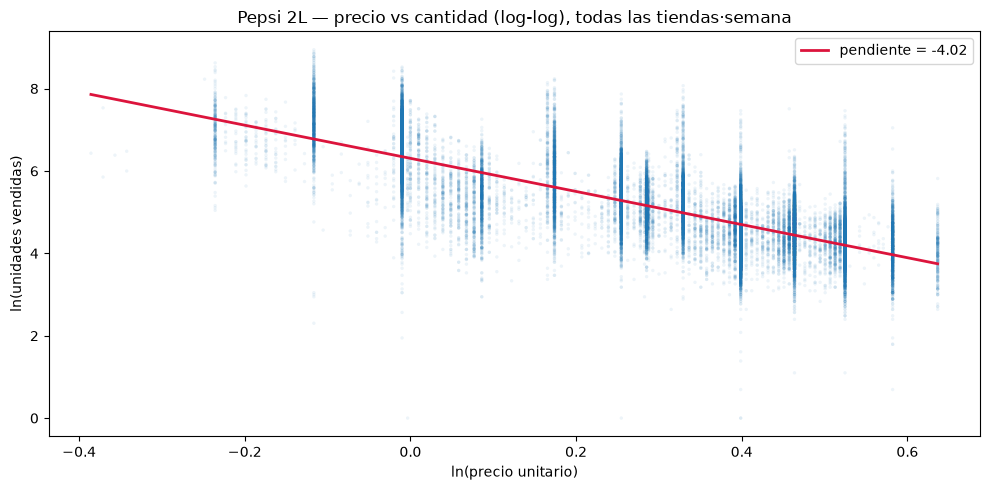

In [ ]:
x = np.log(pepsi['UNIT_PRICE'])
y = np.log(pepsi['MOVE'])

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(x, y, s=6, alpha=.08, edgecolor='none')

# Ajuste visual; No es elasticidad final.
b, a = np.polyfit(x, y, 1) # b = pendiente, a = intercepto
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color='crimson', lw=2, label=f'pendiente = {b:.2f}')

ax.set_xlabel("ln(precio unitario)")
ax.set_ylabel("ln(unidades vendidas)")
ax.set_title("Pepsi 2L — precio vs cantidad (log-log), todas las tiendas·semana")
ax.legend()

plt.tight_layout()
plt.show()

Se puede observar como la nube baja de forma limpia y contundente de izquierda a derecha, es decir, a medida que aumenta el precio se venden menos unidades. Este hecho se encuentra reflejado en la pendiente que tiene un valor negativo (-4.02). Este valor no es la elasticidad real, sino una versión inflada que agrupa todas las tiendas y no diferencia precio original de precios con promoción. La interpretación actual sería que subir el precio un 1% baja las ventas en un 4%. El número real será menor una vez se haga el tratamiento correcto.

Otro punto interesante es la estructura de bandas verticales que presenta el gráfico. Los puntos se concentran principalmente en columnas, por tanto estamos ante precios discretos y no continuos. Cada banda representa un precio y cantidad de unidades concretas vendidas.

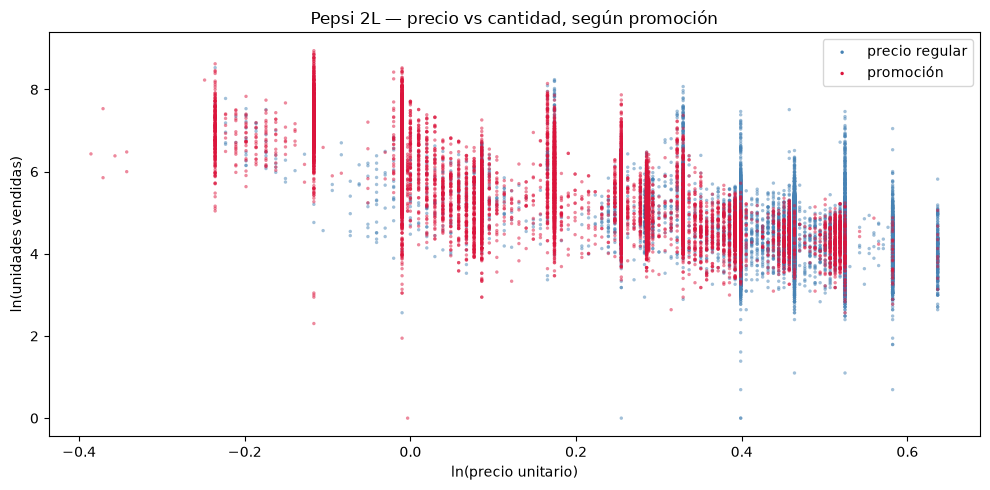

In [36]:
promo = pepsi["SALE"].notna()   # True = hubo promoción

fig, ax = plt.subplots(figsize=(10, 5))

# Precio sin promo
ax.scatter(np.log(pepsi.loc[~promo, "UNIT_PRICE"]), np.log(pepsi.loc[~promo, "MOVE"]),  # ~ operador para invertir lógica. Valores True pasan a ser False y viceversa
           s=6, alpha=0.5, color="steelblue", edgecolor="none", label="precio regular")

# Precio con promo
ax.scatter(np.log(pepsi.loc[promo, "UNIT_PRICE"]), np.log(pepsi.loc[promo, "MOVE"]),
           s=6, alpha=0.50, color="crimson", edgecolor="none", label="promoción")

ax.set_xlabel("ln(precio unitario)")
ax.set_ylabel("ln(unidades vendidas)")
ax.set_title("Pepsi 2L — precio vs cantidad, según promoción")

leg = ax.legend()
for h in leg.legend_handles:  
    h.set_alpha(1)

plt.tight_layout()
plt.show()

Creamos el mismo gráfico pero en esta ocasión mostramos como se distribuyen las ventas y precios cuando se encuentran afectados por promociones. Como cabe esperar, los precios promocionados se concentran en el lado izquierdo del gráfico, en donde las unidades vendidas aumentan y los precios resultan ser más bajos.

Si nos fijamos en el cuadrante In(precio) 0-0.3, los puntos rojos tienden a estar más arriba que los azules, lo que nos indica que al mismo precio, las semanas con promoción venden más que las de precio regular. Por tanto, el efecto "promoción" parece tener un efecto más psicológico más allá de la variación del precio.

Para cerrar el EDA vamos a graficar la serie temporal agregada por unidades y la distribución del precio unitario.

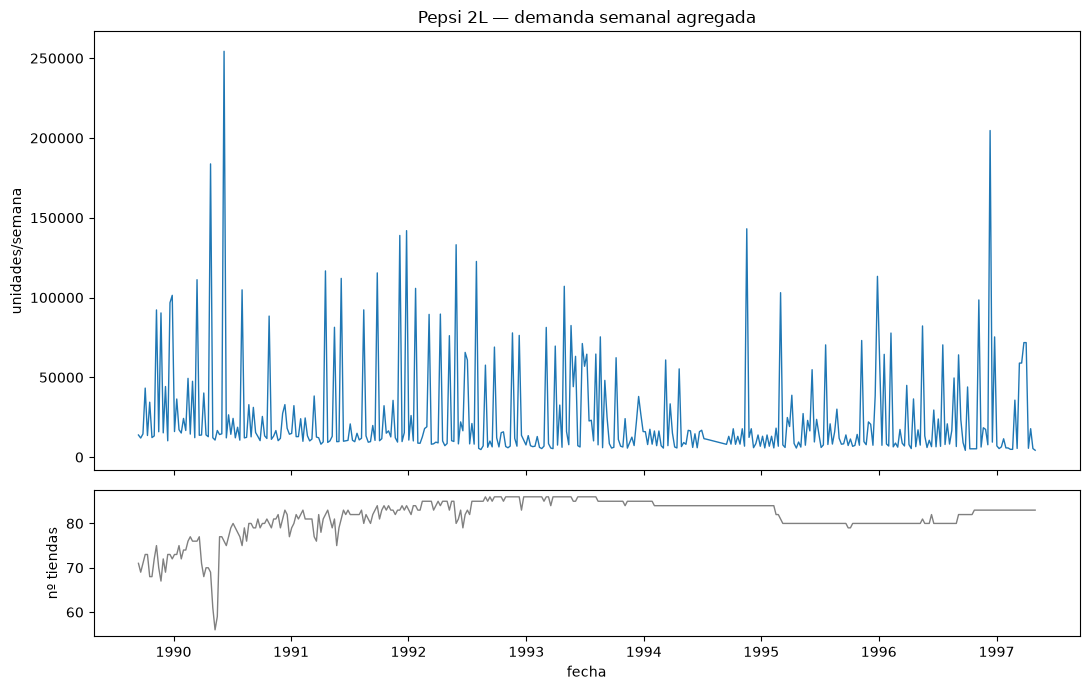

In [41]:
weekly = (
    pepsi.groupby('start') # inicio de semana
    .agg(unidades=('MOVE', 'sum'), n_tiendas=('STORE', 'nunique'))
    .reset_index().sort_values('start')
)

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})

ax[0].plot(weekly["start"], weekly["unidades"], lw=1)
ax[0].set_ylabel("unidades/semana")
ax[0].set_title("Pepsi 2L — demanda semanal agregada")

ax[1].plot(weekly["start"], weekly["n_tiendas"], lw=1, color="gray")
ax[1].set_ylabel("nº tiendas")
ax[1].set_xlabel("fecha")

plt.tight_layout()
plt.show()

Este primer gráfico en donde se puede observar la evolución de las ventas y el número de tiendas sugiere en primer lugar que en la fase inicial de la serie la demanda de bebida aumenta por el aumento de tiendas, lo que nos lleva a eliminar la fase inicial de la serie para el análisis ya que solo añadiría ruido al mismo. Para la descomposición y análisis posterior se van a tomar datos a partir de 1991, en donde el número de tiendas se estabiliza.

En cuanto a la estacionalidad, para poder determinar si hay vamos a realizar un zoom sobre la serie para observar un grupo reducido de años. De esta forma obtendremos una información más precisa.

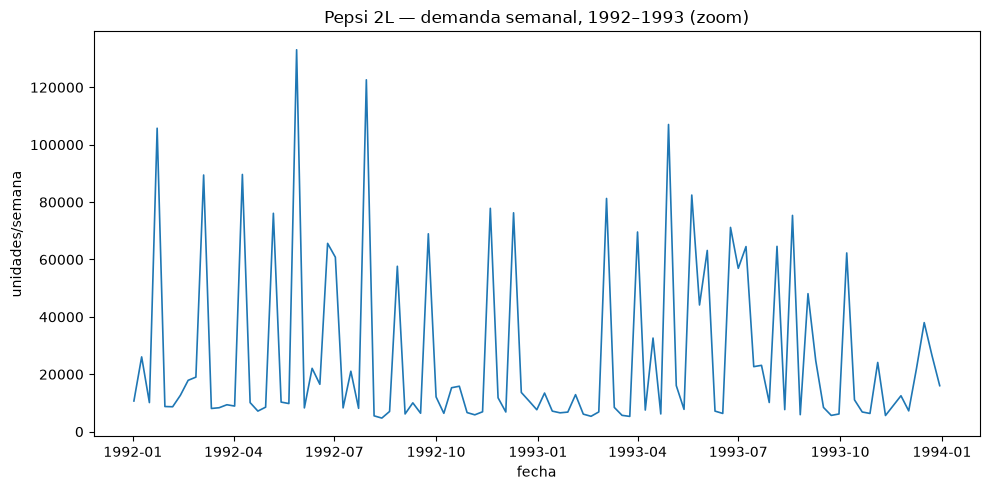

In [44]:
sub = weekly[(weekly['start'] >= '1992-01-01') & (weekly['start'] < '1994-01-01')] # sub-muestra

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(sub['start'], sub['unidades'], lw=1.2)
ax.set_title("Pepsi 2L — demanda semanal, 1992–1993 (zoom)")
ax.set_xlabel("fecha")
ax.set_ylabel("unidades/semana")

plt.tight_layout()
plt.show()

Realizando zoom, lo que queda claro es que la serie destaca principalmente por los picos, que representan promociones. En cuanto a la estacionalidad, se podría decír que está presente y apreciable principalmente en la temporada de invierno en donde el suelo de ventas parece bajar un poco más. Es importante destacar que si bien es cierto que hay estacionalidad, su presencia es muy débil.

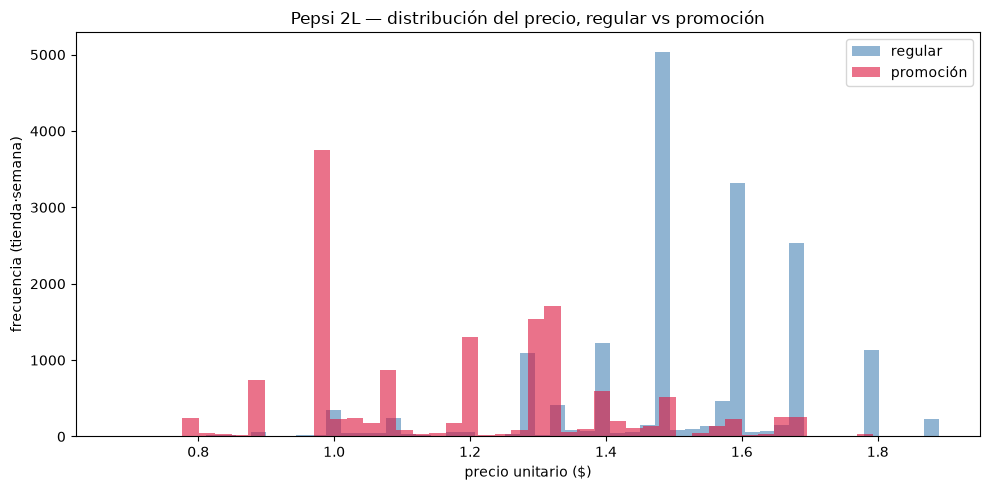

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

# Precio original
ax.hist(pepsi.loc[~promo, "UNIT_PRICE"], bins=50, alpha=0.6, label="regular", color="steelblue")
# Precio promoción
ax.hist(pepsi.loc[promo,  "UNIT_PRICE"], bins=50, alpha=0.6, label="promoción", color="crimson")

ax.set_xlabel("precio unitario ($)")
ax.set_ylabel("frecuencia (tienda·semana)")
ax.set_title("Pepsi 2L — distribución del precio, regular vs promoción")
ax.legend()

plt.tight_layout()
plt.show()

El histograma nos confirma los hallazgos encontrados en el gráfico de puntos. El precio regular se concentra en unos precios determinados, mientras que el precio promocionado se encuentra más disperso y se encuentra principalmente en la zona izquierda.

Lo importante se encuentra en la zona central donde se solapan los precios. En esa zona es donde la regresión nos permite separar el efecto del precio del efecto de la promoción.

In [46]:
pepsi.to_parquet("../data/processed/pepsi_2l.parquet")